Task 1

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample

df = pd.read_csv('creditcard.csv')

fraud = df[df.Class == 1]
normal = df[df.Class == 0]
normal_undersampled = resample(normal, replace=False, n_samples=len(fraud), random_state=42)
df_balanced = pd.concat([fraud, normal_undersampled])

scaler = StandardScaler()
x = df_balanced.drop('Class', axis=1)
y = df_balanced['Class']
x_scaled = scaler.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

rf = RandomForestClassifier()
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

def show_results(name, y_true, y_pred):
    print(f"Results for {name}:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print("-" * 30)
    return f1_score(y_true, y_pred)

f1_lr = show_results("Logistic Regression", y_test, lr_pred)
f1_rf = show_results("Random Forest", y_test, rf_pred)

print("Model Comparison:")
if f1_rf > f1_lr:
    print("Best Model for Imbalanced Data: Random Forest (Higher F1-Score)")
else:
    print("Best Model for Imbalanced Data: Logistic Regression (Higher F1-Score)")
     

Results for Logistic Regression:
Accuracy: 0.9358
Precision: 0.9925
Recall: 0.8800
F1 Score: 0.9329
------------------------------
Results for Random Forest:
Accuracy: 0.9392
Precision: 0.9853
Recall: 0.8933
F1 Score: 0.9371
------------------------------
Model Comparison:
Best Model for Imbalanced Data: Random Forest (Higher F1-Score)


Task 2

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('train (1).csv')

df = df.select_dtypes(include=[np.number])
df = df.fillna(df.median())

x = df.drop('SalePrice', axis=1)
y = df['SalePrice']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)
dt_pred = dt.predict(x_test)

def evaluate(name, actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"{name}:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    comparison = pd.DataFrame({'Actual': actual, 'Predicted': pred}).head(5)
    print("Comparison (First 5):")
    print(comparison)
    print("\n")
    return rmse
linear_rmse = evaluate("Linear Regression", y_test, lr_pred)
decision_rmse = evaluate("Decision Tree Regressor", y_test, dt_pred)
if linear_rmse < decision_rmse:
    print("Best Model: Linear Regression")
else:
    print("Best Model: Decision Tree Regressor")

Linear Regression:
MAE: 23000.03
RMSE: 36879.82
Comparison (First 5):
      Actual      Predicted
892   154500  153728.355878
1105  325000  309240.636439
413   115000  112897.287674
522   159000  180476.649944
1036  315500  294934.414836


Decision Tree Regressor:
MAE: 27084.79
RMSE: 40887.86
Comparison (First 5):
      Actual  Predicted
892   154500   154000.0
1105  325000   424870.0
413   115000   109900.0
522   159000   220000.0
1036  315500   325000.0


Best Model: Linear Regression


Task 3

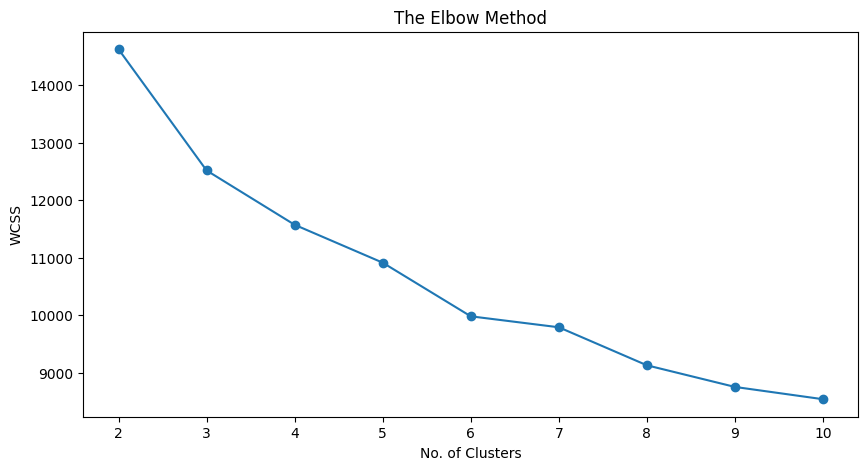

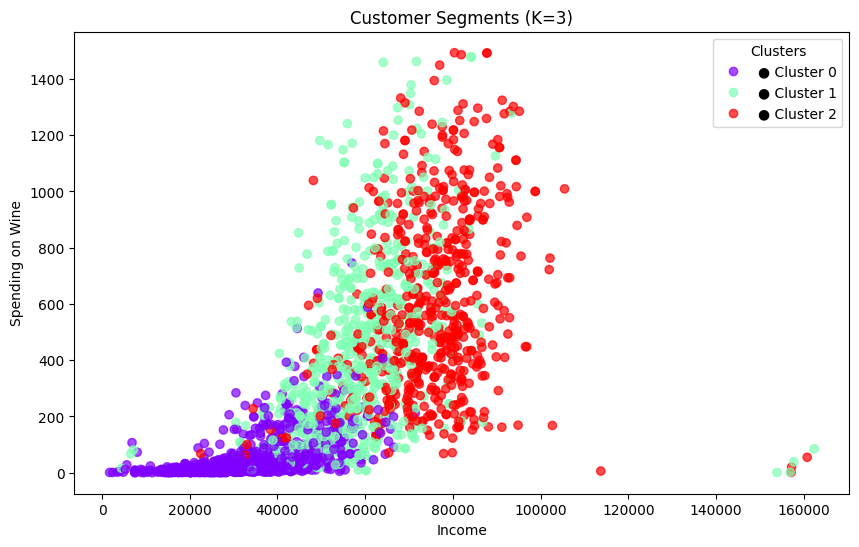

     ID  Cluster
0  5524        2
1  2174        0
2  4141        2
3  6182        0
4  5324        0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mtp
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('marketing_campaign.csv', sep='\t')
df = df.dropna(subset=['Income'])
df = df[df['Income'] < 600000]

features = ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
            'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_subset = df[features]
df_subset = df_subset.fillna(df_subset.median())
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_subset)
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)
mtp.figure(figsize=(10, 5))
mtp.plot(range(2, 11), wcss, marker='o')
mtp.title('The Elbow Method')
mtp.xlabel('No. of Clusters')
mtp.ylabel('WCSS')
mtp.show()
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(x_scaled)

mtp.figure(figsize=(10, 6))
scatter = mtp.scatter(df['Income'], df['MntWines'], c=df['Cluster'], cmap='rainbow', alpha=0.7)
handles, labels = scatter.legend_elements()
legend_labels = [f"● Cluster {i}" for i in range(k_optimal)]
mtp.legend(handles, legend_labels, title="Clusters")
mtp.title(f'Customer Segments (K={k_optimal})')
mtp.xlabel('Income')
mtp.ylabel('Spending on Wine')
mtp.show()
print(df[['ID', 'Cluster']].head())
     